In [1]:
import os
from pathlib import Path
from collections import Counter
import cv2
import matplotlib.pyplot as plt
import yaml

# High resolution plots for thesis
plt.rcParams["figure.dpi"] = 300
plt.rcParams["font.size"] = 11

# Road Damage Detection classes
CLASSES = {0: "Pothole", 1: "Crack", 2: "Manhole"}
CLASS_COLORS = {0: (255, 0, 0), 1: (0, 0, 255), 2: (0, 255, 0)}  # RGB colors

In [2]:
# [Cell 2: Clone Repo & Install Requirements]
REPO_URL = "https://github.com/ariellembong/road-damage-detection-yolo.git"
REPO_DIR = "/kaggle/working/road-damage-detection-yolo"

if not os.path.exists(REPO_DIR):
    !git clone {REPO_URL} {REPO_DIR}
else:
    !cd {REPO_DIR} && git pull

%cd {REPO_DIR}
!pip install -q ultralytics wandb

Cloning into '/kaggle/working/road-damage-detection-yolo'...
remote: Enumerating objects: 31, done.
remote: Counting objects: 100% (31/31), done.
remote: Compressing objects: 100% (23/23), done.
remote: Total 31 (delta 11), reused 27 (delta 7), pack-reused 0 (from 0)
Receiving objects: 100% (31/31), 5.12 MiB | 18.78 MiB/s, done.
Resolving deltas: 100% (11/11), done.
/kaggle/working/road-damage-detection-yolo
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.9/46.9 kB 1.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 25.6 MB/s eta 0:00:0000:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 96.1/96.1 kB 3.4 MB/s eta 0:00:00


In [3]:
# Update these paths to match your local or Kaggle environment
RAW_DATASET_DIR = "/kaggle/input/road-damage-dataset-potholes-cracks-and-manholes/data"
OUTPUT_DIR = "data"

# Run preprocess.py (70% train, 20% val, 10% test)
!python preprocess.py \
    --source {RAW_DATASET_DIR} \
    --dest {OUTPUT_DIR} \
    --train-ratio 0.7 \
    --val-ratio 0.2

✅ Found 2009 valid image-label pairs.
📦 Using 2009 pairs (100% of total).
   📂 train: 1406 samples
   📂 val: 401 samples
   📂 test: 202 samples
📄 Created data.yaml at data/data.yaml

📊 Class Distribution:
   Pothole: 850 (25.9%)
   Crack: 1767 (53.8%)
   Manhole: 670 (20.4%)
   Total Annotations: 3287


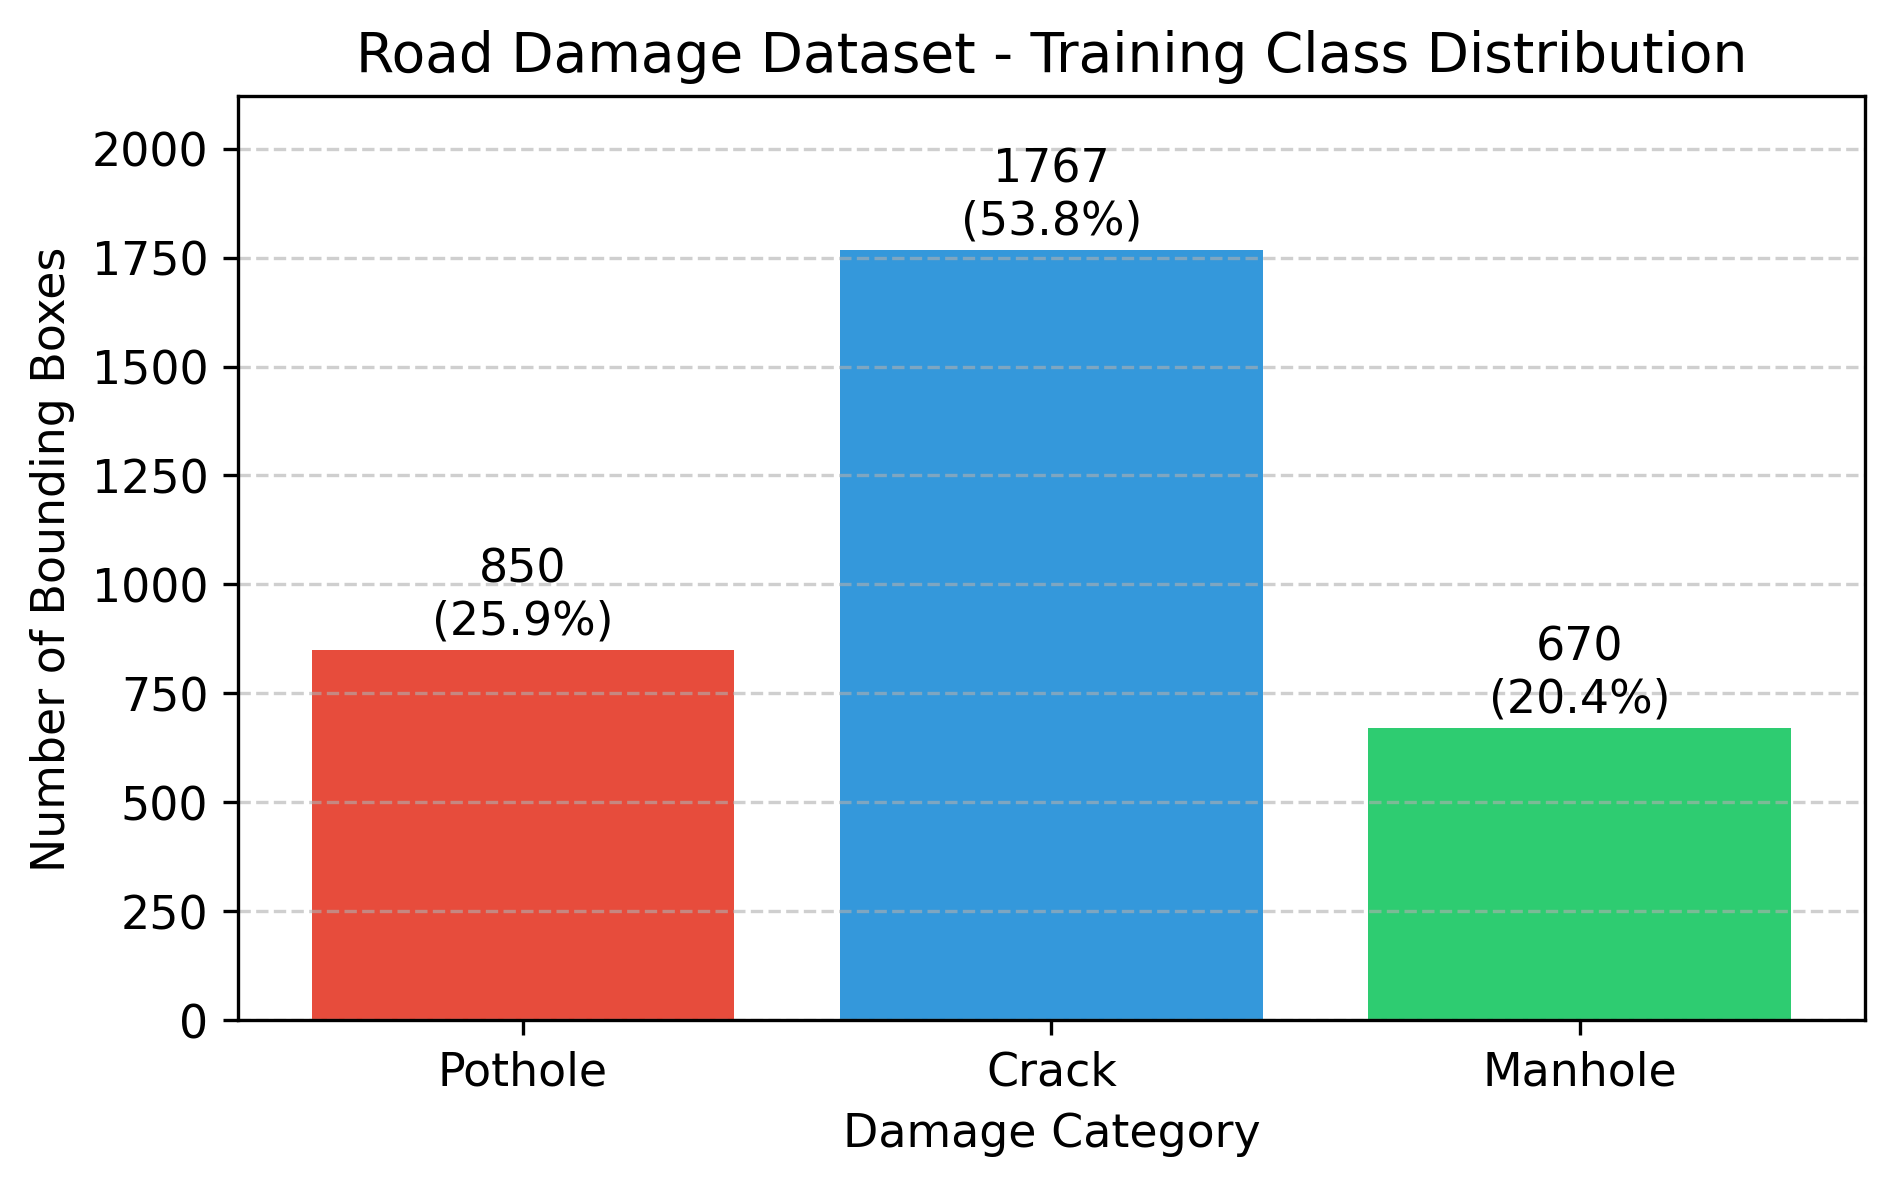

In [4]:
labels_dir = Path(OUTPUT_DIR) / "train" / "labels"
counts = Counter()

for lbl_file in labels_dir.glob("*.txt"):
    with open(lbl_file, "r") as f:
        for line in f:
            parts = line.strip().split()
            if len(parts) >= 5:
                counts[int(parts[0])] += 1

# Prepare data for plotting
names = [CLASSES[k] for k in sorted(counts.keys())]
values = [counts[k] for k in sorted(counts.keys())]
total = sum(values)

plt.figure(figsize=(7, 4))
bars = plt.bar(names, values, color=["#e74c3c", "#3498db", "#2ecc71"])

# Annotate counts and percentages on top of bars
for bar in bars:
    yval = bar.get_height()
    pct = (yval / total) * 100
    plt.text(bar.get_x() + bar.get_width() / 2.0, yval + 15, f"{yval}\n({pct:.1f}%)", ha="center", va="bottom")

plt.title("Road Damage Dataset - Training Class Distribution")
plt.xlabel("Damage Category")
plt.ylabel("Number of Bounding Boxes")
plt.ylim(0, max(values) * 1.2)
plt.grid(axis="y", linestyle="--", alpha=0.6)
plt.savefig("thesis_class_distribution.png", bbox_inches="tight")
plt.show()

In [5]:
yaml_file = Path(OUTPUT_DIR) / "data.yaml"
with open(yaml_file, "r") as f:
    content = yaml.safe_load(f)

print("📄 data.yaml content:")
print(yaml.dump(content, default_flow_style=False))

📄 data.yaml content:
names:
  0: Pothole
  1: Crack
  2: Manhole
path: /kaggle/working/road-damage-detection-yolo/data
test: test/images
train: train/images
val: val/images

